# Respiration Analysis – RI1 Juvenile Interaction

## 1. Imports & Paths
## 2. Load H5 Files
## 3. Load & Preprocess Respiration
## 4. Session QC & Exclusions
## 5. Respiration Rate Extraction
## 6. Grouping (ChR vs GFP)
## 7. Summary Plots & Tables


In [34]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import neurokit2 as nk
import spikeinterface.extractors as se
import matplotlib.pyplot as plt
import h5py
import glob


In [35]:
#H5_DIR = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs"


In [36]:
H5_DIRS = {
    "day1": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs",
    "day2": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs",
}


In [37]:
import glob

H5_DIRS = {
    "day1": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs",
    "day2": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs",
}

resp_all = {}

for day, h5_dir in H5_DIRS.items():
    h5_files = sorted(glob.glob(os.path.join(h5_dir, "*.h5")))

    for h5_file in h5_files:
        sess = os.path.basename(h5_file).replace(".h5", "")

        rsp, t, fs_out, meta = load_clean_resp_signal_ecu(h5_file)

        if rsp is None:
            continue

        resp_all[(sess, day)] = {
            "resp": rsp,
            "time": t,
            "fs": fs_out,
            "meta": meta,
            "day": day
        }


In [67]:
import glob
import os

H5_DIRS = {
    "day1": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs",
    "day2": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs",
}

h5_files = []

for day, d in H5_DIRS.items():
    for f in glob.glob(os.path.join(d, "*.h5")):
        h5_files.append((day, f))

print("Total h5 files:", len(h5_files))


Total h5 files: 48


In [38]:
len(resp_all)


48

In [69]:
import os
import h5py
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk


def load_clean_resp_signal_ecu(h5_file, target_rate=100, fs=20000):
    """
    Loads, filters, downsamples respiration from ECU-style .h5.
    Preserves original preprocessing logic.
    
    Returns:
        rsp_cleaned : np.ndarray
        time_vector : np.ndarray
        fs_out      : float (target_rate)
        metadata    : dict
    """

    try:
        with h5py.File(h5_file, 'r') as f:

            # -----------------------------
            # Load respiration (ECU Ain1)
            # -----------------------------
            analog_keys = list(f['analog'].keys())
            resp_keys = [k for k in analog_keys if "Ain1" in k]
            if len(resp_keys) == 0:
                raise RuntimeError("No ECU Ain1 channel found")

            resp_key = resp_keys[0]
            resp = f['analog'][resp_key][()]['voltage'].astype(float)

            # -----------------------------
            # Metadata (keep for compatibility)
            # -----------------------------
            metadata = {
                "fs_original": fs,
                "source": "ECU_Ain1",
                "file": os.path.basename(h5_file)
            }

    except Exception as e:
        print(f"❌ Error loading {os.path.basename(h5_file)}: {e}")
        return None, None, None, None

    # -----------------------------
    # PRE-CLEAN (CRITICAL)
    # -----------------------------
    # Remove NaNs / infs
    bad = ~np.isfinite(resp)
    if np.any(bad):
        resp[bad] = np.nanmedian(resp)

    # Remove DC offset
    resp = resp - np.median(resp)

    # Clip extreme artifacts (opto / motion)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # -----------------------------
    # Low-pass before downsampling
    # -----------------------------
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # -----------------------------
    # Downsample
    # -----------------------------
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # -----------------------------
    # Bandpass (NeuroKit)
    # -----------------------------
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # -----------------------------
    # Time vector
    # -----------------------------
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate, metadata

In [68]:
resp_all = {}

for day, h5 in h5_files:
    sess = os.path.basename(h5).replace(".h5", "")

    rsp, t, fs, meta = load_clean_resp_signal_ecu(h5)
    if rsp is None:
        continue

    resp_all[sess] = {
        "resp": rsp,
        "time": t,
        "fs": fs,
        "day": day,
        "file": h5
    }


In [72]:
def animal_id_from_sess(sess):
    return "_".join(sess.split("_")[:2])


In [73]:
included_sessions = [
    sess for sess in resp_all
    if animal_id_from_sess(sess) not in excluded_animals
]


In [74]:
results = []

for sess in included_sessions:
    data = resp_all[sess]

    rsp = data["resp"]
    t   = data["time"]
    fs  = data["fs"]
    day = data["day"]

    cage = int(sess.split("_")[0])
    animal_id = animal_id_from_sess(sess)
    sex = "F" if cage <= 4 else "M"

    group, virus = assign_group_and_virus(sess)
    laser = "on" if "_on_" in sess else "off"

    rates = {
        "baseline": get_sniff_respiratory_rate(rsp, t, 0, 60, fs),
        "social":   get_sniff_respiratory_rate(rsp, t, 60, 240, fs)
    }

    for epoch, rate in rates.items():
        results.append({
            "session": sess,
            "animal_id": animal_id,
            "day": day,
            "cage": cage,
            "sex": sex,
            "group": group,
            "virus": virus,
            "laser": laser,
            "epoch": epoch,
            "resp_rate_hz": rate
        })


In [75]:
import pandas as pd
df = pd.DataFrame(results)


In [76]:
df.groupby("animal_id")["day"].nunique()
df.groupby("animal_id")["laser"].nunique()
df.groupby(["animal_id", "day"]).size()


animal_id  day 
1_1        day1    2
           day2    2
1_2        day1    2
           day2    2
1_3        day1    2
           day2    2
2_1        day1    2
           day2    2
2_2        day1    2
           day2    2
3_3        day1    2
           day2    2
4_1        day1    2
           day2    2
4_2        day1    2
           day2    2
4_3        day1    2
           day2    2
7_1        day1    2
           day2    2
7_2        day1    2
           day2    2
7_3        day1    2
           day2    2
8_2        day1    2
           day2    2
8_3        day1    2
           day2    2
9_1        day1    2
           day2    2
dtype: int64

In [77]:
import numpy as np
from scipy.signal import find_peaks


def get_sniff_respiratory_rate(
    signal,
    time,
    sniff_start,
    sniff_end,
    sampling_rate=100,
    max_rate_hz=12
):
    """
    Compute average respiration/sniff rate using inter-breath intervals (IBI).
    
    Returns:
        avg_rate_hz (float) or np.nan
    """

    # -----------------------------
    # Mask window
    # -----------------------------
    sniff_mask = (time >= sniff_start) & (time < sniff_end)

    if sniff_mask.sum() < sampling_rate:  # <1 s of data
        return np.nan

    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # -----------------------------
    # Pre-clean for peak detection
    # -----------------------------
    signal_sniff = signal_sniff - np.mean(signal_sniff)

    # -----------------------------
    # Peak detection
    # -----------------------------
    min_ibi = 1.0 / max_rate_hz
    min_distance = int(min_ibi * sampling_rate)

    peaks, _ = find_peaks(
        signal_sniff,
        distance=min_distance
    )

    if len(peaks) < 2:
        return np.nan

    # -----------------------------
    # IBI and rate
    # -----------------------------
    peak_times = time_sniff[peaks]
    ibi = np.diff(peak_times)          # seconds
    inst_rate = 1.0 / ibi              # Hz

    return np.mean(inst_rate)


In [ ]:
excluded_animals = {
    "2_3",
    "3_1",
    "3_2",
    "5_1",
    "5_2",
    "5_3",
    "6_2",
    "6_3",
    "8_1",
}

In [78]:
def assign_sex(sess):
    cage = int(sess.split("_")[0])
    return "F" if cage <= 4 else "M"


In [79]:
def assign_laser(sess):
    return "on" if "_on_" in sess else "off"


In [80]:
def assign_group_and_virus(sess):
    cage_num = int(sess.split("_")[0])
    if cage_num % 2 == 1:
        return "A", "ChR"
    else:
        return "B", "GFP"

In [81]:
results = []

for sess, data in resp_all.items():

    if sess not in included_sessions:
        continue

    rsp = data["resp"]
    t   = data["time"]
    fs  = data["fs"]

    group, virus = assign_group_and_virus(sess)
    laser = assign_laser(sess)
    sex   = assign_sex(sess)

    baseline_rate = get_sniff_respiratory_rate(
        rsp, t, 0, 60, sampling_rate=fs
    )

    social_rate = get_sniff_respiratory_rate(
        rsp, t, 60, 240, sampling_rate=fs
    )

    results.append({
        "session": sess,
        "animal_id": sess.split("_RI1")[0],
        "cage": int(sess.split("_")[0]),
        "sex": sex,
        "group": group,
        "virus": virus,
        "laser": laser,
        "baseline_rate_hz": baseline_rate,
        "social_rate_hz": social_rate,
        "delta_rate_hz": social_rate - baseline_rate
    })


In [82]:
import pandas as pd
df = pd.DataFrame(results)


In [83]:
df.head()


,session,animal_id,cage,sex,group,virus,laser,baseline_rate_hz,social_rate_hz,delta_rate_hz
0,1_1_RI1_f1_d_on_20260111_164638,1_1,1,F,A,ChR,on,9.263738,9.152318,-0.111419
1,1_2_RI1_f2_f_off_20260109_165330,1_2,1,F,A,ChR,off,9.683383,10.288113,0.604731
2,1_3_RI1_f1_c_off_20260110_130254,1_3,1,F,A,ChR,off,9.113699,8.591796,-0.521902
3,2_1_RI1_f2_h_on_20260110_145355,2_1,2,F,B,GFP,on,10.237224,9.249470,-0.987754
4,2_2_RI1_f1_b_off_20260109_150435,2_2,2,F,B,GFP,off,9.062868,8.654789,-0.408079


In [84]:
def is_excluded(sess, excluded_animals):
    # assumes session names start with animal ID like "3_2_..."
    animal_id = sess.split("_RI1")[0]
    return animal_id in excluded_animals

included_sessions = [
    sess for sess in resp_all.keys()
    if not is_excluded(sess, excluded_animals)
]

print("Included sessions:")
for s in included_sessions:
    print(" ", s)


Included sessions:
  1_1_RI1_f1_d_on_20260111_164638
  1_2_RI1_f2_f_off_20260109_165330
  1_3_RI1_f1_c_off_20260110_130254
  2_1_RI1_f2_h_on_20260110_145355
  2_2_RI1_f1_b_off_20260109_150435
  3_3_RI1_f1_c_on_20260111_162426
  4_1_RI1_f2_h_on_20260111_161337
  4_2_RI1_f1_c_off_20260110_150626
  4_3_RI1_f2_e_on_20260111_152801
  7_1_RI1_m1_k_on_20260111_160052
  7_2_RI1_m2_o_off_20260109_162132
  7_3_RI1_m1_i_on_20260110_142124
  8_2_RI1_m1_k_off_20260109_144621
  8_3_RI1_m2_p_on_20260110_134333
  9_1_RI1_m2_m_on_20260111_165857
  1_1_RI1_f2_e_off_20260110_154830
  1_2_RI1_f1_b_on_20260110_192621
  1_3_RI1_f2_g_on_20260111_145128
  2_1_RI1_f1_d_off_20260111_143848
  2_2_RI1_f2_f_on_20260110_162056
  3_3_RI1_f2_f_off_20260110_163905
  4_1_RI1_f1_b_off_20260110_165525
  4_2_RI1_f2_g_on_20260111_130824
  4_3_RI1_f1_d_off_20260110_185633
  6_2_RI2_m2_n_on_20260110_190944
  7_1_RI1_m2_p_off_20260110_183014
  7_2_RI1_m1_k_on_20260110_170840
  7_3_RI1_m2_n_off_20260111_134312
  8_2_RI1_m2_o_o

In [85]:
results = []

for sess in included_sessions:
    data = resp_all[sess]
    rsp = data["resp"]
    t   = data["time"]
    fs  = data["fs"]

    group, virus = assign_group_and_virus(sess)
    laser = "on" if "_on_" in sess else "off"

    rates = {
        "baseline": get_sniff_respiratory_rate(
            rsp, t, 0, 60, sampling_rate=fs
        ),
        "social": get_sniff_respiratory_rate(
            rsp, t, 60, 240, sampling_rate=fs
        )
    }

    for epoch, rate in rates.items():
        results.append({
            "session": sess,
            "animal_id": sess.split("_RI1")[0],
            "cage": int(sess.split("_")[0]),
            "group": group,
            "virus": virus,
            "laser": laser,
            "epoch": epoch,
            "resp_rate_hz": rate
        })


In [86]:
list(resp_all.keys())[15]


'5_3_RI1_m1_k_off_20260109_183135'

In [87]:
type(next(iter(resp_all.keys())))


str

In [ ]:
import pandas as pd
df = pd.DataFrame(results)
df.head()


,session,animal_id,cage,group,virus,laser,epoch,resp_rate_hz
0,1_1_RI1_f2_e_off_20260110_154830,1_1,1,A,ChR,off,baseline,9.961040
1,1_1_RI1_f2_e_off_20260110_154830,1_1,1,A,ChR,off,social,8.928348
2,1_2_RI1_f1_b_on_20260110_192621,1_2,1,A,ChR,on,baseline,9.466535
3,1_2_RI1_f1_b_on_20260110_192621,1_2,1,A,ChR,on,social,8.960292
4,1_3_RI1_f2_g_on_20260111_145128,1_3,1,A,ChR,on,baseline,8.516600


In [92]:
df.head()


,session,animal_id,cage,sex,group,virus,laser,baseline_rate_hz,social_rate_hz,delta_rate_hz
0,1_1_RI1_f1_d_on_20260111_164638,1_1,1,F,A,ChR,on,9.263738,9.152318,-0.111419
1,1_2_RI1_f2_f_off_20260109_165330,1_2,1,F,A,ChR,off,9.683383,10.288113,0.604731
2,1_3_RI1_f1_c_off_20260110_130254,1_3,1,F,A,ChR,off,9.113699,8.591796,-0.521902
3,2_1_RI1_f2_h_on_20260110_145355,2_1,2,F,B,GFP,on,10.237224,9.249470,-0.987754
4,2_2_RI1_f1_b_off_20260109_150435,2_2,2,F,B,GFP,off,9.062868,8.654789,-0.408079


In [93]:
df_long = df.melt(
    id_vars=["animal_id", "virus", "laser", "sex"],
    value_vars=["baseline_rate_hz", "social_rate_hz"],
    var_name="epoch",
    value_name="resp_rate_hz"
)

df_long["epoch"] = df_long["epoch"].map({
    "baseline_rate_hz": "baseline",
    "social_rate_hz": "social"
})

In [94]:
summary = (
    df_long
    .groupby(["virus", "laser", "sex", "epoch"])
    .agg(
        mean_rate=("resp_rate_hz", "mean"),
        sem_rate=("resp_rate_hz", "sem")
    )
    .reset_index()
)

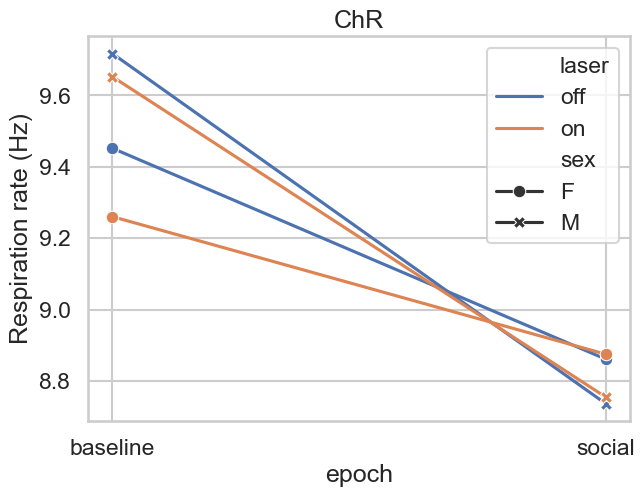

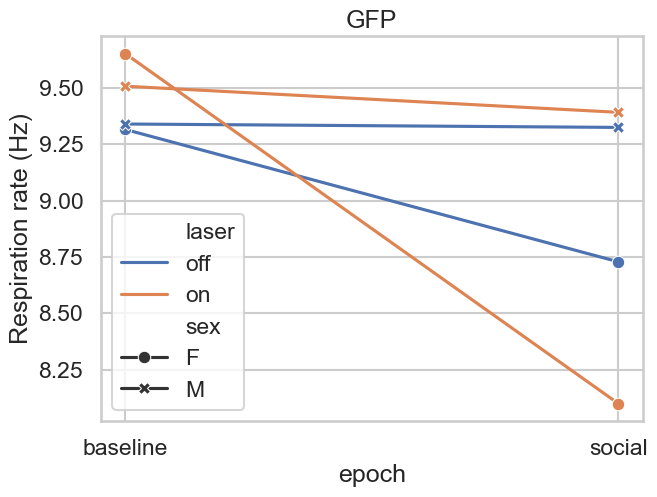

In [96]:
for virus in ["ChR", "GFP"]:
    plt.figure(figsize=(7,5))
    sns.lineplot(
        data=summary[summary["virus"] == virus],
        x="epoch",
        y="mean_rate",
        hue="laser",
        style="sex",
        markers=True,
        dashes=False
    )
    plt.title(virus)
    plt.ylabel("Respiration rate (Hz)")
    plt.show()



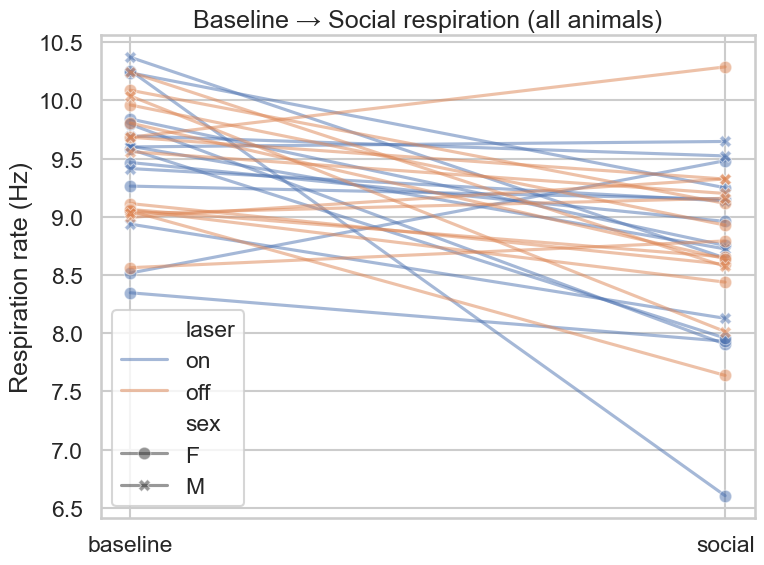

In [97]:
plt.figure(figsize=(8,6))

sns.lineplot(
    data=df_long,
    x="epoch",
    y="resp_rate_hz",
    hue="laser",
    style="sex",
    units="animal_id",
    estimator=None,
    alpha=0.5,
    markers=True,
    dashes=False
)

plt.ylabel("Respiration rate (Hz)")
plt.xlabel("")
plt.title("Baseline → Social respiration (all animals)")
plt.tight_layout()
plt.show()


In [99]:
df_long = df.melt(
    id_vars=["animal_id", "virus", "laser", "sex"],
    value_vars=["baseline_rate_hz", "social_rate_hz"],
    var_name="epoch",
    value_name="resp_rate_hz"
)

df_long["epoch"] = df_long["epoch"].map({
    "baseline_rate_hz": "baseline",
    "social_rate_hz": "social"
})

epoch_order = ["baseline", "social"]


In [100]:
sex_colors = {
    "M": "#1f77b4",   # blue
    "F": "#e377c2"    # pink
}


In [101]:
import matplotlib.pyplot as plt

def plot_resp_lines(df, virus):
    fig, axes = plt.subplots(
        nrows=1, ncols=2, figsize=(10,5), sharey=True
    )

    for ax, laser in zip(axes, ["off", "on"]):
        sub = df[(df["virus"] == virus) & (df["laser"] == laser)]

        for animal_id, d in sub.groupby("animal_id"):
            d = d.sort_values("epoch")

            sex = d["sex"].iloc[0]
            color = sex_colors[sex]

            ax.plot(
                d["epoch"],
                d["resp_rate_hz"],
                marker="o",
                color=color,
                alpha=0.7,
                linewidth=2
            )

        ax.set_title(f"{virus} | Laser {laser.upper()}")
        ax.set_xlabel("")
        ax.set_xticks(range(len(epoch_order)))
        ax.set_xticklabels(epoch_order)

    axes[0].set_ylabel("Respiration rate (Hz)")
    fig.suptitle(f"{virus}: Baseline → Social respiration", fontsize=16)
    plt.tight_layout()
    plt.show()


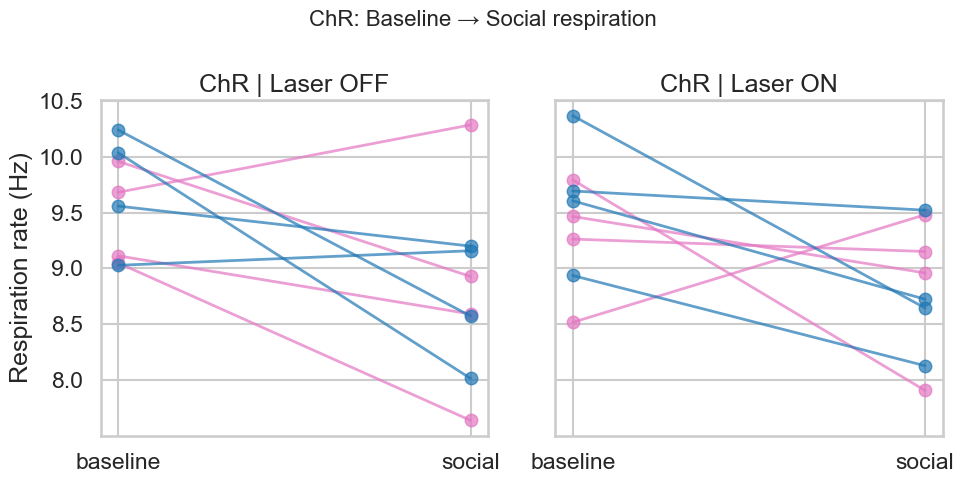

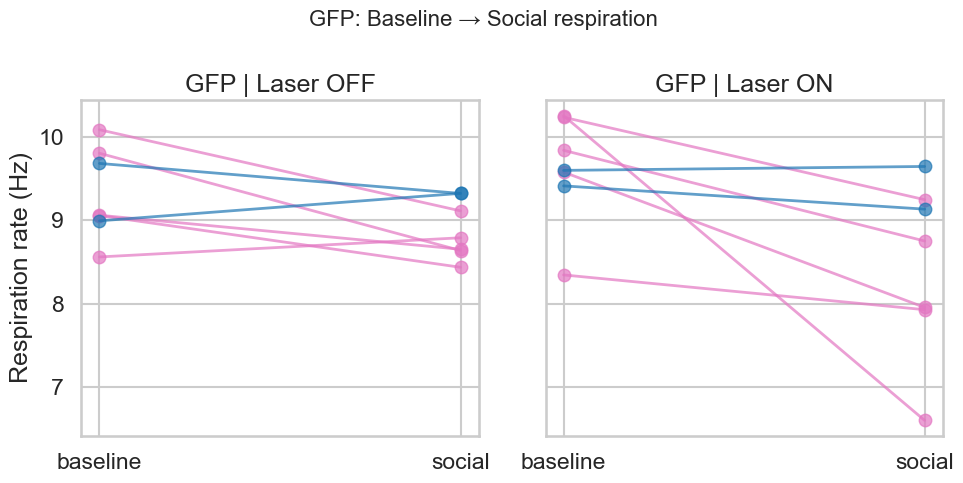

In [102]:
plot_resp_lines(df_long, virus="ChR")
plot_resp_lines(df_long, virus="GFP")


In [103]:
import numpy as np

summary = (
    df_long
    .groupby(["virus", "laser", "epoch"])
    .agg(
        mean_rate=("resp_rate_hz", "mean"),
        sem_rate=("resp_rate_hz", lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
    )
    .reset_index()
)


In [108]:
import matplotlib.pyplot as plt

def plot_resp_lines_with_mean(df_long, summary, virus):
    fig, axes = plt.subplots(
        nrows=1, ncols=2, figsize=(11,5), sharey=True
    )

    for ax, laser in zip(axes, ["off", "on"]):
        sub = df_long[(df_long["virus"] == virus) & (df_long["laser"] == laser)]
        summ = summary[(summary["virus"] == virus) & (summary["laser"] == laser)]

        # -----------------------------
        # Individual mouse lines
        # -----------------------------
        for animal_id, d in sub.groupby("animal_id"):
            d = d.sort_values("epoch")
            sex = d["sex"].iloc[0]
            color = sex_colors[sex]

            ax.plot(
                d["epoch"],
                d["resp_rate_hz"],
                marker="o",
                color=color,
                alpha=0.6,
                linewidth=2
            )

        # -----------------------------
        # Mean ± SEM overlay
        # -----------------------------
        summ = summ.set_index("epoch").loc[["baseline", "social"]]

        ax.errorbar(
            x=["baseline", "social"],
            y=summ["mean_rate"],
            yerr=summ["sem_rate"],
            color="black",
            linewidth=3,
            marker="o",
            capsize=6,
            zorder=10,
            label="Mean ± SEM"
        )

        ax.set_title(f"{virus} | Laser {laser.upper()}")
        ax.set_xlabel("")
        ax.set_xticks(["baseline", "social"])
        ax.set_xticklabels(["baseline", "social"])

    axes[0].set_ylabel("Respiration rate (Hz)")
    fig.suptitle(f"{virus}: Baseline → Social respiration", fontsize=16)


    plt.tight_layout()
    plt.show()


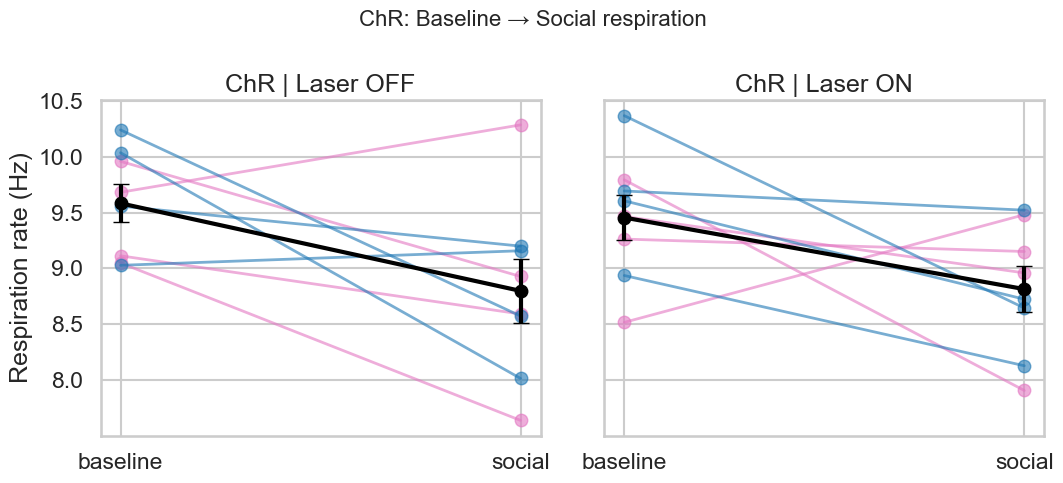

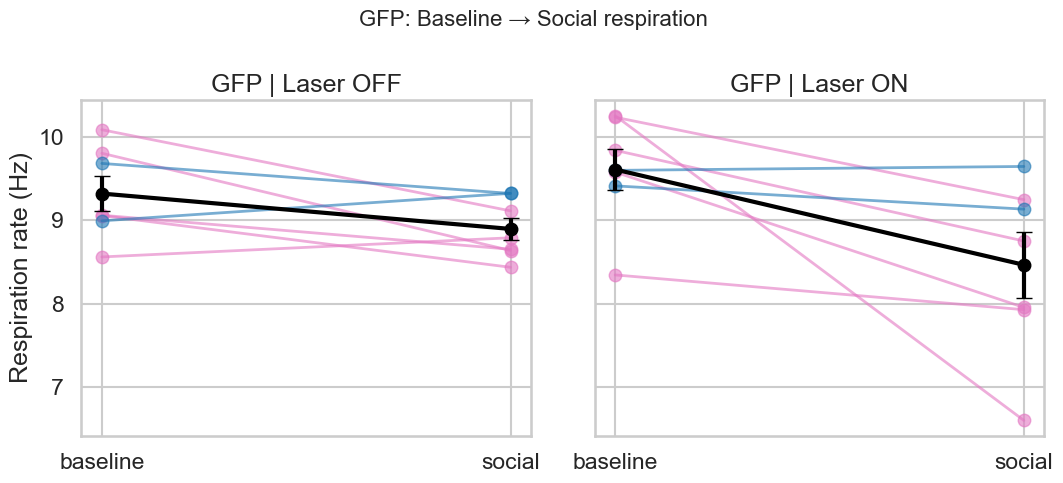

In [109]:
plot_resp_lines_with_mean(df_long, summary, virus="ChR")
plot_resp_lines_with_mean(df_long, summary, virus="GFP")


In [121]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "delta_rate_hz ~ laser * virus",
    df,
    groups=df["animal_id"]
)

res = model.fit()
print(res.summary())


               Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   delta_rate_hz
No. Observations:     30        Method:               REML         
No. Groups:           15        Scale:                0.7455       
Min. group size:      2         Log-Likelihood:       -39.0896     
Max. group size:      2         Converged:            Yes          
Mean group size:      2.0                                          
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.786    0.331 -2.370 0.018 -1.435 -0.136
laser[T.on]               0.144    0.432  0.334 0.738 -0.702  0.990
virus[T.GFP]              0.362    0.485  0.746 0.456 -0.589  1.313
laser[T.on]:virus[T.GFP] -0.863    0.632 -1.366 0.172 -2.102  0.376
Group Var                 0.134    0.325                       

In [122]:
df_laser = df.copy()
df_laser["resp_social"] = df_laser["social_rate_hz"]


In [123]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "resp_social ~ laser * virus",
    df_laser,
    groups=df_laser["animal_id"]
)

res = model.fit()
print(res.summary())


               Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    resp_social
No. Observations:     30         Method:                REML       
No. Groups:           15         Scale:                 0.3377     
Min. group size:      2          Log-Likelihood:        -32.1099   
Max. group size:      2          Converged:             Yes        
Mean group size:      2.0                                          
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 8.799    0.262 33.536 0.000  8.285  9.313
laser[T.on]               0.016    0.291  0.055 0.956 -0.553  0.586
virus[T.GFP]              0.099    0.384  0.259 0.796 -0.653  0.852
laser[T.on]:virus[T.GFP] -0.446    0.425 -1.049 0.294 -1.280  0.387
Group Var                 0.213    0.364                       